<a href="https://colab.research.google.com/github/2326-aar/Task-1/blob/main/heart_Failure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

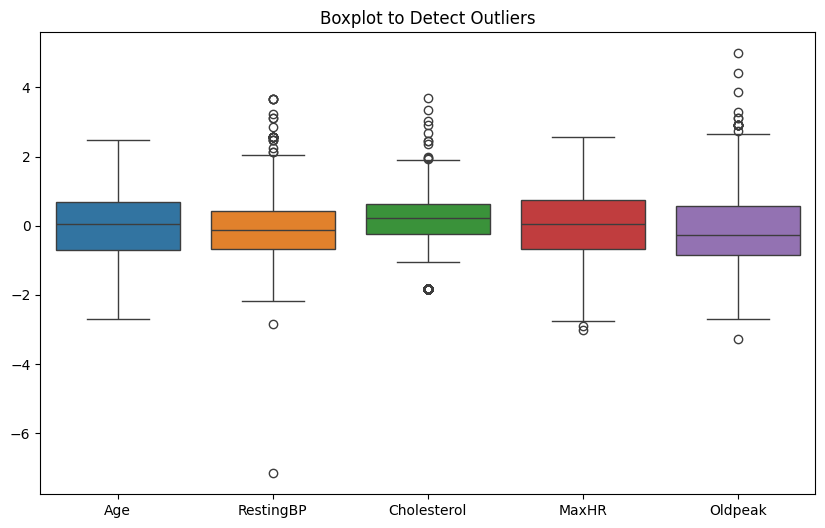


Cleaned Data Preview:
         Age  Sex  RestingBP  Cholesterol  FastingBS     MaxHR  ExerciseAngina  \
0 -1.433140    1   0.410909     0.825070          0  1.382928               0   
1 -0.478484    0   1.491752    -0.171961          0  0.754157               0   
2 -1.751359    1  -0.129513     0.770188          0 -1.525138               0   
3 -0.584556    0   0.302825     0.139040          0 -1.132156               1   
4  0.051881    1   0.951331    -0.034755          0 -0.581981               0   

    Oldpeak  HeartDisease  ChestPainType_ATA  ChestPainType_NAP  \
0 -0.832432             0               True              False   
1  0.105664             1              False               True   
2 -0.832432             0               True              False   
3  0.574711             1              False              False   
4 -0.832432             0              False               True   

   ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ST_Slope_Flat  \
0             

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats

# Step 2: Load Dataset
df = pd.read_csv("/content/heart Failure prediction Dataset.csv")
print(df.head())
print(df.info())

# Step 3: Check and Handle Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# Step 4: Encode Categorical Features
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])

# One-hot encoding for other categorical columns
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

# Step 5: Normalize / Standardize Numeric Features
scaler = StandardScaler()
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Step 6: Visualize Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot to Detect Outliers")
plt.show()

# Step 7: Remove Outliers using Z-Score
df = df[(np.abs(stats.zscore(df[num_cols])) < 3).all(axis=1)]

# Step 8: Final Data Overview
print("\nCleaned Data Preview:\n", df.head())
print("\nData Shape After Cleaning:", df.shape)
